In [3]:
import pandas as pd

csv = pd.read_csv('/media/Volume/data/PTB-XL/ptbxl_database.csv')
csv.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


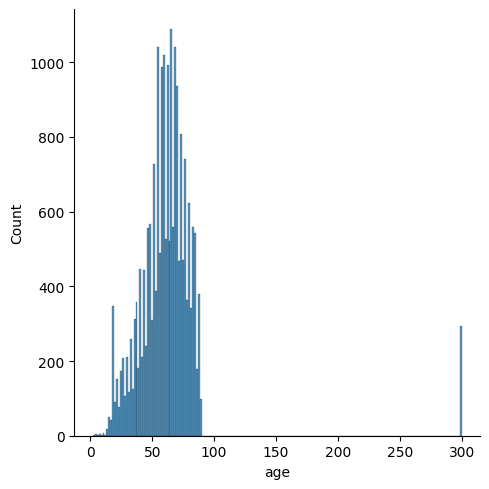

In [ ]:
import seaborn as sns

# plot the distribution of age of the patients

sns.displot(csv['age'])

In [25]:
import pandas as pd

csv = pd.read_csv('/media/Volume/data/MIMIC_IV/exams_filtered.csv')
lvef = pd.read_csv('/media/Volume/data/MIMIC_IV/lvef.csv')
csv.head()

,Unnamed: 0,file_name,study_id,subject_id,ecg_time,ed_stay_id,ed_hadm_id,hosp_hadm_id,ed_diag_ed,ed_diag_hosp,...,age,anchor_year,anchor_age,dod,ecg_no_within_stay,ecg_taken_in_ed,ecg_taken_in_hosp,ecg_taken_in_ed_or_hosp,fold,strat_fold
0,0,files/p1000/p10000032/s40689238/40689238,40689238,10000032,2180-07-23 08:44:00,39399961.0,29079034.0,NaN,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I958...",...,52.0,2180.0,52.0,2180-09-09,0,True,False,True,17,9
1,1,files/p1000/p10000032/s44458630/44458630,44458630,10000032,2180-07-23 09:54:00,39399961.0,29079034.0,NaN,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I958...",...,52.0,2180.0,52.0,2180-09-09,1,True,False,True,17,9
2,2,files/p1000/p10000032/s49036311/49036311,49036311,10000032,2180-08-06 09:07:00,NaN,NaN,25742920.0,[],[],...,52.0,2180.0,52.0,2180-09-09,0,False,True,True,17,9
3,3,files/p1000/p10000117/s45090959/45090959,45090959,10000117,2181-03-04 17:14:00,NaN,NaN,NaN,[],[],...,55.0,2174.0,48.0,NaN,-1,False,False,False,18,0
4,4,files/p1000/p10000117/s48446569/48446569,48446569,10000117,2183-09-18 13:52:00,33176849.0,27988844.0,NaN,"['S72092A', 'W1830XA']","['K219', 'F419', 'Z7901', 'Z87891', 'G43909', ...",...,57.0,2174.0,48.0,NaN,0,True,False,True,18,0


In [30]:
print('number of patients', len(csv['subject_id'].unique()))
print('number of exams', len(csv))
print('number of patients having lvef', len(lvef['subject_id'].unique()))
print('number of exams having lvef', len(lvef))

# keep only the patients that have lvef
filtered = csv[csv['subject_id'].isin(lvef['subject_id'])]
print('number of patients after filtering', len(csv['subject_id'].unique()))
print('total number of exams', len(filtered))

number of patients 160856
number of exams 788945
number of patients having lvef 19486
number of exams having lvef 75412
number of patients after filtering 160856
total number of exams 262324


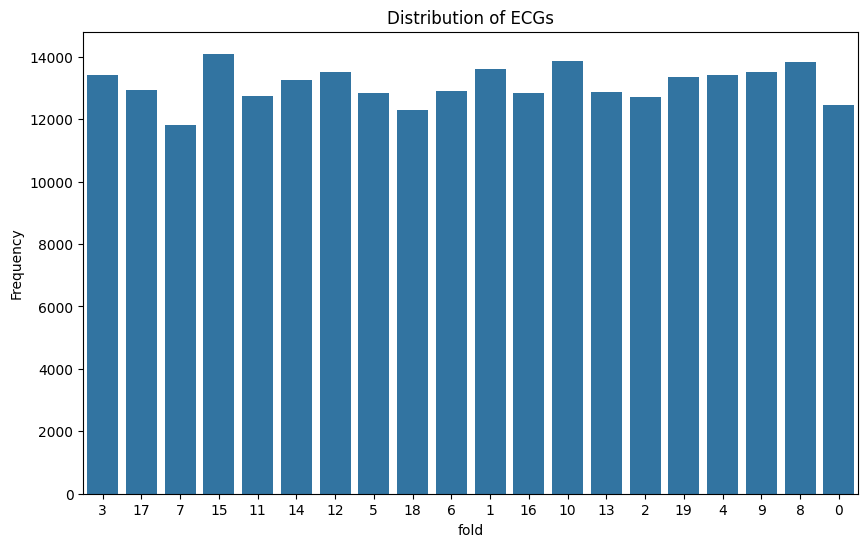

In [33]:


# plot the distribution for every fold (with sns)
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(data, column, title):
    plt.figure(figsize=(10, 6))
    sns.countplot(x=data[column].astype(str))  # Force categorical
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# Plot the distribution of age
plot_distribution(filtered, 'fold', 'Distribution of ECGs')

